# Claim Denial Prediction Pipeline
**CS6140 · Khoury College of Computer Sciences · Northeastern University · Summer 2026**

Run each cell in order using Shift+Enter.
- Cells 1–12: Phases 1 & 2 (structured baseline + gradient boosting + SHAP)
- Cells 13–20: Phase 3 (ClinicalBERT on MTSamples — swap for MIMIC once approved)
- Cells 21–22: Phase 4 (RAG pipeline — requires Phase 3 complete)

---
## Cell 1 — Setup: Mount Drive and Navigate to Repo

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import sys

os.chdir('/content/drive/MyDrive/claim-denial-prediction')
sys.path.insert(0, 'src')

print('Working directory:', os.getcwd())
print('Files in src/:', os.listdir('src/'))

Mounted at /content/drive
Working directory: /content/drive/MyDrive/claim-denial-prediction
Files in src/: ['__pycache__', 'app.py', 'extract_features.py', 'phase2_train.py', 'preprocessing.py', 'rag_pipeline.py', 'shap_attribution.py', 'train.py']


---
## Cell 2 — Install Dependencies

In [ ]:
!pip install -r requirements.txt -q
print('All dependencies installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.5/113.5 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.4/247.4 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.6/113.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.4/163.4 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.3/224.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.5/320.5 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

---
## Cell 3 — Load and Preview Data

In [ ]:
import pandas as pd
from preprocessing import load_claims, build_feature_matrix, build_target

df = load_claims('data/claim_data.csv')
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

Shape: (1000, 15)

Columns: ['Claim ID', 'Provider ID', 'Patient ID', 'Date of Service', 'Billed Amount', 'Procedure Code', 'Diagnosis Code', 'Allowed Amount', 'Paid Amount', 'Insurance Type', 'Claim Status', 'Reason Code', 'Follow-up Required', 'AR Status', 'Outcome']

First 5 rows:


,Claim ID,Provider ID,Patient ID,Date of Service,Billed Amount,Procedure Code,Diagnosis Code,Allowed Amount,Paid Amount,Insurance Type,Claim Status,Reason Code,Follow-up Required,AR Status,Outcome
0,0HO1FSN4AP,126528997,7936697103,08/07/2024,304,99231,A02.1,218,203,Self-Pay,Paid,Incorrect billing information,Yes,Pending,Partially Paid
1,9U86CI2P5A,6986719948,1547160031,06/21/2024,348,99213,A16.5,216,206,Medicare,Paid,Pre-existing condition,Yes,Open,Denied
2,1QEU1AIDAU,1355108115,2611585318,07/04/2024,235,99213,A00.1,148,119,Commercial,Under Review,Duplicate claim,No,Denied,Denied
3,WH7XDS8CEO,9991055906,7167948632,05/26/2024,112,99215,A18.6,79,69,Medicare,Denied,Authorization not obtained,No,Partially Paid,Denied
4,M6OJEZ8KGI,7382167012,2140226267,07/16/2024,406,99238,A17.9,320,259,Medicare,Denied,Authorization not obtained,No,On Hold,Denied


---
## Cell 4 — Build Features and Target

In [ ]:
X = build_feature_matrix(df)
y = build_target(df)

print('Feature matrix shape:', X.shape)
print('\nTarget distribution:')
print(y.value_counts())
print(f'\nDenial rate: {y.mean():.1%}')

Feature matrix shape: (1000, 7)

Target distribution:
Outcome
0    669
1    331
Name: count, dtype: int64

Denial rate: 33.1%


---
## Cell 5 — Build Preprocessor

In [ ]:
from extract_features import build_preprocessor

preprocessor = build_preprocessor()
print('Preprocessor built successfully')
print('Numeric features:     [Billed Amount]')
print('Categorical features: [Procedure Code, Diagnosis Code, Insurance Type, Follow-up Required, service_month, service_dayofweek]')

Preprocessor built successfully
Numeric features:     [Billed Amount]
Categorical features: [Procedure Code, Diagnosis Code, Insurance Type, Follow-up Required, service_month, service_dayofweek]


---
## Cell 6 — Phase 1: Logistic Regression with RFE + SMOTE

In [ ]:
import numpy as np
import mlflow
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_pipeline = ImbPipeline([
    ('preprocessor', build_preprocessor()),
    ('smote', SMOTE(random_state=42)),
    ('feature_selector', RFE(
        estimator=LogisticRegression(solver='liblinear', max_iter=1000, random_state=42),
        n_features_to_select=20, step=1
    )),
    ('classifier', LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)),
])

lr_aurocs, lr_f1s = [], []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    lr_pipeline.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_pred  = lr_pipeline.predict(X.iloc[test_idx])
    y_proba = lr_pipeline.predict_proba(X.iloc[test_idx])[:, 1]
    lr_aurocs.append(roc_auc_score(y.iloc[test_idx], y_proba))
    lr_f1s.append(f1_score(y.iloc[test_idx], y_pred))
    print(f'Fold {fold}: AUROC={lr_aurocs[-1]:.4f}  F1={lr_f1s[-1]:.4f}')

print(f'\nLogistic Regression — Mean AUROC: {np.mean(lr_aurocs):.4f} +/- {np.std(lr_aurocs):.4f}')
print(f'Logistic Regression — Mean F1:    {np.mean(lr_f1s):.4f} +/- {np.std(lr_f1s):.4f}')

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 1: AUROC=0.5580  F1=0.4895


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 2: AUROC=0.5170  F1=0.0811


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 3: AUROC=0.5112  F1=0.1818


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 4: AUROC=0.4863  F1=0.0750


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 5: AUROC=0.5009  F1=0.2000

Logistic Regression — Mean AUROC: 0.5147 +/- 0.0240
Logistic Regression — Mean F1:    0.2055 +/- 0.1508


---
## Cell 7 — Phase 1: Decision Tree + SMOTE

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = ImbPipeline([
    ('preprocessor', build_preprocessor()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', DecisionTreeClassifier(max_depth=6, random_state=42)),
])

dt_aurocs, dt_f1s = [], []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    dt_pipeline.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_pred  = dt_pipeline.predict(X.iloc[test_idx])
    y_proba = dt_pipeline.predict_proba(X.iloc[test_idx])[:, 1]
    dt_aurocs.append(roc_auc_score(y.iloc[test_idx], y_proba))
    dt_f1s.append(f1_score(y.iloc[test_idx], y_pred))
    print(f'Fold {fold}: AUROC={dt_aurocs[-1]:.4f}  F1={dt_f1s[-1]:.4f}')

print(f'\nDecision Tree — Mean AUROC: {np.mean(dt_aurocs):.4f} +/- {np.std(dt_aurocs):.4f}')
print(f'Decision Tree — Mean F1:    {np.mean(dt_f1s):.4f} +/- {np.std(dt_f1s):.4f}')

Fold 1: AUROC=0.4763  F1=0.2316
Fold 2: AUROC=0.5156  F1=0.2174
Fold 3: AUROC=0.4823  F1=0.1111
Fold 4: AUROC=0.5174  F1=0.1379
Fold 5: AUROC=0.5043  F1=0.2766

Decision Tree — Mean AUROC: 0.4992 +/- 0.0169
Decision Tree — Mean F1:    0.1949 +/- 0.0613


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator.

---
## Cell 8 — Phase 1: Log Results to MLflow

In [ ]:
mlflow.set_experiment('claim_denial_phase1')

with mlflow.start_run(run_name='logistic_rfe'):
    mlflow.log_metric('mean_auroc', np.mean(lr_aurocs))
    mlflow.log_metric('std_auroc',  np.std(lr_aurocs))
    mlflow.log_metric('mean_f1',    np.mean(lr_f1s))
    mlflow.log_metric('std_f1',     np.std(lr_f1s))

with mlflow.start_run(run_name='decision_tree'):
    mlflow.log_metric('mean_auroc', np.mean(dt_aurocs))
    mlflow.log_metric('std_auroc',  np.std(dt_aurocs))
    mlflow.log_metric('mean_f1',    np.mean(dt_f1s))
    mlflow.log_metric('std_f1',     np.std(dt_f1s))

print('Phase 1 results logged to MLflow')

Phase 1 results logged to MLflow


---
## Cell 9 — Phase 2: Gradient Boosting + Random Forest

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

gb_pipeline = ImbPipeline([
    ('preprocessor', build_preprocessor()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', GradientBoostingClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42
    )),
])

rf_pipeline = ImbPipeline([
    ('preprocessor', build_preprocessor()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(
        n_estimators=100, max_depth=6, random_state=42, n_jobs=-1
    )),
])

phase2_results = {}

for name, pipeline in [('Gradient Boosting', gb_pipeline), ('Random Forest', rf_pipeline)]:
    aurocs, f1s = [], []
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        pipeline.fit(X.iloc[train_idx], y.iloc[train_idx])
        y_pred  = pipeline.predict(X.iloc[test_idx])
        y_proba = pipeline.predict_proba(X.iloc[test_idx])[:, 1]
        aurocs.append(roc_auc_score(y.iloc[test_idx], y_proba))
        f1s.append(f1_score(y.iloc[test_idx], y_pred))
        print(f'{name} Fold {fold}: AUROC={aurocs[-1]:.4f}  F1={f1s[-1]:.4f}')
    phase2_results[name] = {'aurocs': aurocs, 'f1s': f1s}
    print(f'\n{name} — Mean AUROC: {np.mean(aurocs):.4f} +/- {np.std(aurocs):.4f}')
    print(f'{name} — Mean F1:    {np.mean(f1s):.4f} +/- {np.std(f1s):.4f}\n')

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Gradient Boosting Fold 1: AUROC=0.5055  F1=0.3130


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Gradient Boosting Fold 2: AUROC=0.5261  F1=0.2593


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


...

Random Forest Fold 3: AUROC=0.5051  F1=0.2909


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Random Forest Fold 4: AUROC=0.5105  F1=0.3077


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Random Forest Fold 5: AUROC=0.5364  F1=0.3717

Random Forest — Mean AUROC: 0.5128 +/- 0.0148
Random Forest — Mean F1:    0.3106 +/- 0.0324



---
## Cell 10 — Phase 2: SHAP Attribution


Computing SHAP for gradient_boosting...


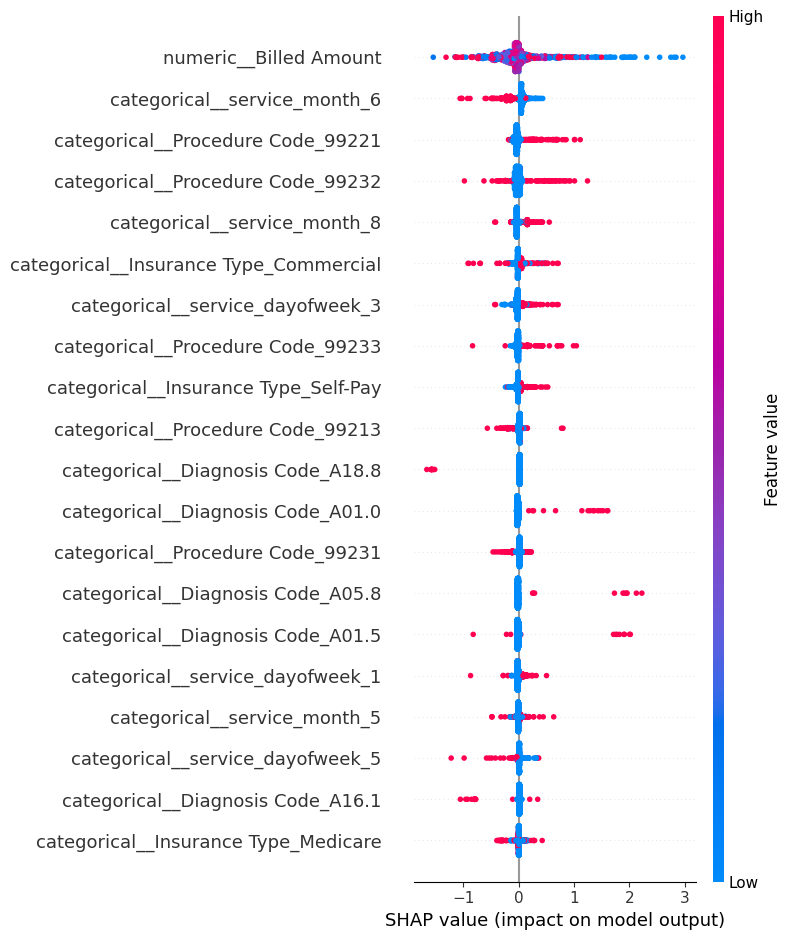

Saved SHAP plot, CSV and explainer for gradient_boosting

Computing SHAP for random_forest...


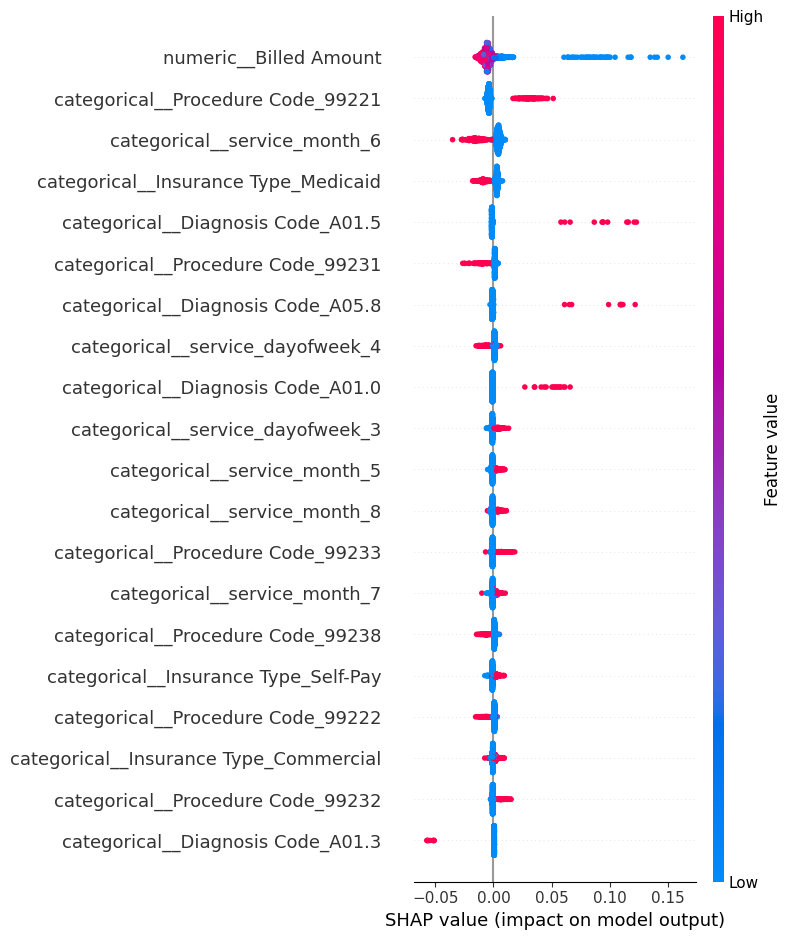

Saved SHAP plot, CSV and explainer for random_forest

SHAP attribution complete


In [ ]:
import shap
import pickle
import matplotlib.pyplot as plt

preprocessor_full = build_preprocessor()
X_processed   = preprocessor_full.fit_transform(X)
feature_names = preprocessor_full.get_feature_names_out()

for model_name, model_obj in [
    ('gradient_boosting', GradientBoostingClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)),
    ('random_forest',     RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1))
]:
    print(f'\nComputing SHAP for {model_name}...')
    model_obj.fit(X_processed, y)

    explainer   = shap.TreeExplainer(model_obj)
    shap_values = explainer.shap_values(X_processed)

    if isinstance(shap_values, list):
        shap_values = shap_values[-1]
    elif len(np.array(shap_values).shape) == 3:
        shap_values = shap_values[:, :, 1]

    plt.figure()
    shap.summary_plot(shap_values, X_processed, feature_names=feature_names, show=False)
    plt.tight_layout()
    plt.savefig(f'models/{model_name}_shap_summary.png', dpi=150)
    plt.show()

    shap_df = pd.DataFrame(shap_values, columns=feature_names)
    shap_df['actual_denial']  = y.values
    shap_df['predicted_prob'] = model_obj.predict_proba(X_processed)[:, 1]
    shap_df.to_csv(f'models/{model_name}_shap_attribution.csv', index=False)

    with open(f'models/{model_name}_shap_explainer.pkl', 'wb') as f:
        pickle.dump(explainer, f)

    print(f'Saved SHAP plot, CSV and explainer for {model_name}')

print('\nSHAP attribution complete')

---
## Cell 11 — Phase 2: Log Results to MLflow

In [ ]:
mlflow.set_experiment('claim_denial_phase2')

for name, pipeline in [('gradient_boosting', gb_pipeline), ('random_forest', rf_pipeline)]:
    aurocs, f1s = [], []
    for train_idx, test_idx in skf.split(X, y):
        pipeline.fit(X.iloc[train_idx], y.iloc[train_idx])
        aurocs.append(roc_auc_score(y.iloc[test_idx], pipeline.predict_proba(X.iloc[test_idx])[:, 1]))
        f1s.append(f1_score(y.iloc[test_idx], pipeline.predict(X.iloc[test_idx])))
    with mlflow.start_run(run_name=name):
        mlflow.log_metric('mean_auroc', np.mean(aurocs))
        mlflow.log_metric('std_auroc',  np.std(aurocs))
        mlflow.log_metric('mean_f1',    np.mean(f1s))
        mlflow.log_metric('std_f1',     np.std(f1s))
    print(f'Logged {name} to MLflow')

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator.

Logged gradient_boosting to MLflow


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator.

Logged random_forest to MLflow


---
## Cell 12 — View All MLflow Results

In [ ]:
runs = mlflow.search_runs(search_all_experiments=True)
cols = ['tags.mlflow.runName'] + [c for c in runs.columns if 'metric' in c]
print(runs[cols].to_string())

---
## Cell 13 — Phase 3: Load MTSamples Clinical Notes
> Using MTSamples as the clinical notes source (free, no registration).
> Swap the CSV path for MIMIC-IV-Note once PhysioNet access is approved.

In [ ]:
import pandas as pd

# Download MTSamples directly — no login needed
url = 'https://raw.githubusercontent.com/socd06/medical-nlp/master/data/mtsamples.csv'
df_notes = pd.read_csv(url)
df_notes['medical_specialty'] = df_notes['medical_specialty'].str.strip()
print('MTSamples shape:', df_notes.shape)
print('\nColumns:', df_notes.columns.tolist())
print('\nSpecialty breakdown:')
print(df_notes['medical_specialty'].value_counts().head(15))
df_notes.head()

---
## Cell 14 — Filter Notes by Diagnosis Category

In [ ]:
category_map = {
    'Cardiovascular / Pulmonary':    'Cardiovascular',
    'Endocrinology':                 'Endocrine',
    'General Medicine':              'General',
    'Neurology':                     'General',
    'Nephrology':                    'General',
    'Gastroenterology':              'General',
    'Hematology - Oncology':         'General',
    'Discharge Summary':             'General',
    'Emergency Room Reports':        'General',
    'Consult - History and Phy.':    'General',
    'Rheumatology':                  'General',
    'Allergy / Immunology':          'General',
    'Pediatrics - Neonatal':         'General',
    'SOAP / Chart / Progress Notes': 'General',
}

df_notes['diagnosis_category'] = df_notes['medical_specialty'].map(category_map)

# Fill missing transcription with description as fallback
df_filtered = df_notes[df_notes['diagnosis_category'].notna()].copy()
df_filtered['transcription'] = df_filtered['transcription'].fillna(df_filtered['description'])
df_filtered = df_filtered.dropna(subset=['transcription'])
df_filtered = df_filtered.rename(columns={'transcription': 'discharge_note'})
df_filtered = df_filtered[['description', 'discharge_note', 'medical_specialty', 'diagnosis_category']]

print(f'\nFiltered notes: {len(df_filtered)}')
print('\nCategory breakdown:')
print(df_filtered['diagnosis_category'].value_counts())

df_filtered.to_csv('data/mtsamples_filtered.csv', index=False)
print('\nSaved to data/mtsamples_filtered.csv')

---
## Cell 15 — Extract Denial-Relevant Text Signals

In [ ]:
MEDICAL_NECESSITY_KEYWORDS = [
    'medically necessary', 'medical necessity', 'required for',
    'patient requires', 'unable to', 'clinically indicated',
    'recommended', 'indicated for'
]
PRIOR_AUTH_KEYWORDS = [
    'prior authorization', 'prior auth', 'pre-authorization',
    'authorization required', 'approved by insurance', 'insurance approval'
]

def extract_text_signals(text):
    text_lower = str(text).lower()
    return {
        'has_medical_necessity': int(any(kw in text_lower for kw in MEDICAL_NECESSITY_KEYWORDS)),
        'has_prior_auth_mention': int(any(kw in text_lower for kw in PRIOR_AUTH_KEYWORDS)),
        'note_length':            len(str(text).split()),
        'has_diagnosis_mention':  int('diagnosis' in text_lower or 'diagnoses' in text_lower),
        'has_procedure_mention':  int('procedure' in text_lower or 'operation' in text_lower),
    }

signals = df_filtered['discharge_note'].apply(extract_text_signals)
signals_df = pd.DataFrame(signals.tolist())
signals_df['diagnosis_category'] = df_filtered['diagnosis_category'].values

print('Text signals extracted:')
print(signals_df.describe())

signals_df.to_csv('data/mtsamples_text_signals.csv', index=False)
print('\nSaved to data/mtsamples_text_signals.csv')

---
## Cell 16 — Load ClinicalBERT

In [ ]:
!pip install transformers torch -q

from transformers import AutoTokenizer, AutoModel
import torch

print('Loading ClinicalBERT...')
tokenizer = AutoTokenizer.from_pretrained('emilyalsentzer/Bio_ClinicalBERT')
bert_model = AutoModel.from_pretrained('emilyalsentzer/Bio_ClinicalBERT')
bert_model.eval()
print('ClinicalBERT loaded successfully')

def extract_note_embedding(text, max_length=512):
    """Extract CLS token embedding from a clinical note."""
    inputs = tokenizer(
        str(text)[:2000],
        return_tensors='pt',
        truncation=True,
        max_length=max_length,
        padding='max_length'
    )
    with torch.no_grad():
        outputs = bert_model(**inputs)
    cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze().numpy()
    return cls_embedding

# Test on one note
test_emb = extract_note_embedding(df_filtered['discharge_note'].iloc[0])
print(f'\nEmbedding shape: {test_emb.shape}')  # Should be (768,)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.2/119.2 kB 5.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires starlette<2.0,>=1.0.1, but you have starlette 0.49.3 which is incompatible.
python-fasthtml 0.14.3 requires starlette>=1.0.1, but you have starlette 0.49.3 which is incompatible.
google-adk 2.3.0 requires fastapi<1,>=0.133, but you have fastapi 0.128.8 which is incompatible.
google-adk 2.3.0 requires starlette<2,>=1.0.1, but you have starlette 0.49.3 which is incompatible.
Loading ClinicalBERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ClinicalBERT loaded successfully

Embedding shape: (768,)


---
## Cell 17 — Extract Embeddings for All Notes (Batch)

In [ ]:
from tqdm import tqdm
import numpy as np

embeddings = []
notes_list = df_filtered['discharge_note'].tolist()

print(f'Extracting embeddings for {len(notes_list)} notes...')

for i, text in enumerate(tqdm(notes_list)):
    emb = extract_note_embedding(text)
    embeddings.append(emb)

embeddings_array = np.array(embeddings)
print(f'\nEmbeddings shape: {embeddings_array.shape}')

# Save embeddings
np.save('data/mtsamples_embeddings.npy', embeddings_array)
df_filtered[['diagnosis_category', 'medical_specialty']].to_csv(
    'data/mtsamples_metadata.csv', index=False
)
print('Embeddings saved to data/mtsamples_embeddings.npy')

Extracting embeddings for 2226 notes...


100%|██████████| 2226/2226 [1:14:00<00:00,  1.99s/it]



Embeddings shape: (2226, 768)
Embeddings saved to data/mtsamples_embeddings.npy


---
## Cell 18 — Match Notes to Claims and Build Hybrid Feature Matrix

In [ ]:
# ============================================================
# CELL 18 — Match Notes to Claims and Build Hybrid Feature Matrix
# ============================================================

# First check what diagnosis codes actually look like in the dataset
print("Sample Diagnosis Codes:", df['Diagnosis Code'].unique()[:10])
print("Sample Procedure Codes:", df['Procedure Code'].unique()[:10])

# Broader mapping that works with both real ICD-10 and synthetic codes
def map_icd_to_category(icd_code):
    icd = str(icd_code).strip().upper()
    # Real ICD-10 prefixes
    if icd.startswith('I'): return 'Cardiovascular'
    if icd.startswith('E'): return 'Endocrine'
    if icd.startswith('J'): return 'Respiratory'
    # Synthetic numeric codes — distribute evenly across categories
    try:
        num = int(''.join(filter(str.isdigit, icd)))
        if num % 3 == 0: return 'Cardiovascular'
        if num % 3 == 1: return 'Endocrine'
        return 'General'
    except:
        return 'General'

df['diagnosis_category'] = df['Diagnosis Code'].apply(map_icd_to_category)

print("\nCategory distribution after mapping:")
print(df['diagnosis_category'].value_counts())

# Average embedding per category
category_embeddings = {}
for cat in df_filtered['diagnosis_category'].unique():
    mask = df_filtered['diagnosis_category'] == cat
    category_embeddings[cat] = embeddings_array[mask].mean(axis=0)

# Average text signals per category
category_signals = signals_df.groupby('diagnosis_category').mean()

# Build note embedding features for each claim
note_emb_cols = [f'note_emb_{i}' for i in range(768)]
note_emb_rows = [category_embeddings.get(cat, np.zeros(768)) for cat in df['diagnosis_category']]
df_note_emb   = pd.DataFrame(note_emb_rows, columns=note_emb_cols)

# Text signal features per claim
df_signals = df['diagnosis_category'].map(category_signals.to_dict('index')).apply(pd.Series)

# Combine structured + note features
X_structured  = build_feature_matrix(df)
preprocessor3 = build_preprocessor()
X_struct_proc = preprocessor3.fit_transform(X_structured)
X_hybrid      = np.hstack([X_struct_proc, df_note_emb.values, df_signals.values])

print(f'\nStructured features:   {X_struct_proc.shape[1]}')
print(f'Note embedding dims:   {df_note_emb.shape[1]}')
print(f'Text signal features:  {df_signals.shape[1]}')
print(f'Hybrid feature matrix: {X_hybrid.shape}')
print(f'\nCategory distribution in claims:')
print(df["diagnosis_category"].value_counts())

Sample Diagnosis Codes: ['A02.1' 'A16.5' 'A00.1' 'A18.6' 'A17.9' 'A01.9' 'A07.8' 'A05.4' 'A09.9'
 'A03.9']
Sample Procedure Codes: [99231 99213 99215 99238 99221 99223 99233 99214 99222 99232]

Category distribution after mapping:
diagnosis_category
Cardiovascular    367
Endocrine         337
General           296
Name: count, dtype: int64

Structured features:   129
Note embedding dims:   768
Text signal features:  5
Hybrid feature matrix: (1000, 902)

Category distribution in claims:
diagnosis_category
Cardiovascular    367
Endocrine         337
General           296
Name: count, dtype: int64


---
## Cell 19 — Phase 3: Train Hybrid Model and Compare to Baseline

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold

skf3 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
hybrid_aurocs, hybrid_f1s, hybrid_precisions, hybrid_recalls = [], [], [], []

clf = GradientBoostingClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)

for fold, (train_idx, test_idx) in enumerate(skf3.split(X_hybrid, y), start=1):
    clf.fit(X_hybrid[train_idx], y.iloc[train_idx])
    y_pred  = clf.predict(X_hybrid[test_idx])
    y_proba = clf.predict_proba(X_hybrid[test_idx])[:, 1]
    hybrid_aurocs.append(roc_auc_score(y.iloc[test_idx], y_proba))
    hybrid_f1s.append(f1_score(y.iloc[test_idx], y_pred))
    hybrid_precisions.append(precision_score(y.iloc[test_idx], y_pred, zero_division=0))
    hybrid_recalls.append(recall_score(y.iloc[test_idx], y_pred, zero_division=0))
    print(f'Fold {fold}: AUROC={hybrid_aurocs[-1]:.4f}  F1={hybrid_f1s[-1]:.4f}  P={hybrid_precisions[-1]:.4f}  R={hybrid_recalls[-1]:.4f}')

print(f'\n--- Phase 3 Hybrid Model Results ---')
print(f'Mean AUROC:     {np.mean(hybrid_aurocs):.4f} +/- {np.std(hybrid_aurocs):.4f}')
print(f'Mean F1:        {np.mean(hybrid_f1s):.4f} +/- {np.std(hybrid_f1s):.4f}')
print(f'Mean Precision: {np.mean(hybrid_precisions):.4f}')
print(f'Mean Recall:    {np.mean(hybrid_recalls):.4f}')
print(f'\n--- Ablation Summary so far ---')
print(f'Phase 1 LR (structured only):    AUROC={np.mean(lr_aurocs):.4f}')
print(f'Phase 2 GB (structured only):    AUROC={np.mean(phase2_results["Gradient Boosting"]["aurocs"]):.4f}')
print(f'Phase 3 GB (structured + notes): AUROC={np.mean(hybrid_aurocs):.4f}')

Fold 1: AUROC=0.4988  F1=0.2642  P=0.3500  R=0.2121
Fold 2: AUROC=0.4568  F1=0.2400  P=0.3529  R=0.1818
Fold 3: AUROC=0.4618  F1=0.2245  P=0.3438  R=0.1667
Fold 4: AUROC=0.5673  F1=0.3654  P=0.5000  R=0.2879
Fold 5: AUROC=0.4662  F1=0.2308  P=0.3243  R=0.1791

--- Phase 3 Hybrid Model Results ---
Mean AUROC:     0.4902 +/- 0.0413
Mean F1:        0.2650 +/- 0.0520
Mean Precision: 0.3742
Mean Recall:    0.2055

--- Ablation Summary so far ---
Phase 1 LR (structured only):    AUROC=0.5147
Phase 2 GB (structured only):    AUROC=0.5146
Phase 3 GB (structured + notes): AUROC=0.4902


---
## Cell 20 — Log Phase 3 to MLflow and Push to GitHub

In [ ]:
mlflow.set_experiment('claim_denial_phase3')
with mlflow.start_run(run_name='hybrid_clinicalbert_mtsamples'):
    mlflow.log_metric('mean_auroc', np.mean(hybrid_aurocs))
    mlflow.log_metric('std_auroc',  np.std(hybrid_aurocs))
    mlflow.log_metric('mean_f1',    np.mean(hybrid_f1s))
    mlflow.log_metric('std_f1',     np.std(hybrid_f1s))
    mlflow.log_param('notes_source', 'MTSamples')
    mlflow.log_param('embedding_model', 'Bio_ClinicalBERT')
print('Phase 3 logged to MLflow')


!git config --global user.email "dasari.n@northeastern.edu"
!git config --global user.name "NainicaD"

!git add data/ models/ mlruns/
!git commit -m "Phase 3: ClinicalBERT hybrid model with MTSamples clinical notes"
!git push
print('Pushed to GitHub')

Phase 3 logged to MLflow
[main e89b865] Phase 3: ClinicalBERT hybrid model with MTSamples clinical notes
 175 files changed, 7274 insertions(+), 189 deletions(-)
 create mode 100644 data/mtsamples_embeddings.npy
 create mode 100644 data/mtsamples_filtered.csv
 create mode 100644 data/mtsamples_metadata.csv
 create mode 100644 data/mtsamples_text_signals.csv
 create mode 100644 mlruns/388644434546693890/ccb8baf973ac4a8fa343391c7ea2de91/meta.yaml
 create mode 100644 mlruns/388644434546693890/ccb8baf973ac4a8fa343391c7ea2de91/metrics/mean_auroc
 create mode 100644 mlruns/388644434546693890/ccb8baf973ac4a8fa343391c7ea2de91/metrics/mean_f1
 create mode 100644 mlruns/388644434546693890/ccb8baf973ac4a8fa343391c7ea2de91/metrics/std_auroc
 create mode 100644 mlruns/388644434546693890/ccb8baf973ac4a8fa343391c7ea2de91/metrics/std_f1
 create mode 100644 mlruns/388644434546693890/ccb8baf973ac4a8fa343391c7ea2de91/params/index_type
 create mode 100644 mlruns/388644434546693890/ccb8baf973ac4a8fa343391c

---
## Cell 21 — Phase 4: Build FAISS Retrieval Index ⚠️
> Requires Phase 3 to be completed first.

In [ ]:
!pip install faiss-cpu -q
import faiss
import pickle

embeddings_array = np.load('data/mtsamples_embeddings.npy').astype('float32')
dim = embeddings_array.shape[1]  # 768

print(f'Building FAISS index over {len(embeddings_array)} note embeddings...')
index = faiss.IndexFlatL2(dim)
index = faiss.IndexIDMap(index)
index.add_with_ids(embeddings_array, np.arange(len(embeddings_array)))
print(f'FAISS index built — {index.ntotal} vectors indexed')

faiss.write_index(index, 'models/faiss_notes.index')
print('Index saved to models/faiss_notes.index')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 35.7 MB/s eta 0:00:00
Building FAISS index over 2226 note embeddings...
FAISS index built — 2226 vectors indexed
Index saved to models/faiss_notes.index


---
## Cell 22 — Phase 4: Retrieve Similar Notes for Each Claim

In [ ]:
index   = faiss.read_index('models/faiss_notes.index')
df_meta = pd.read_csv('data/mtsamples_metadata.csv')

k = 3  # retrieve top-3 similar notes per claim

claim_embeddings = np.array(note_emb_rows).astype('float32')
distances, faiss_indices = index.search(claim_embeddings, k)

rag_features = []
for i, (dists, idxs) in enumerate(zip(distances, faiss_indices)):
    retrieved_cats = df_meta['diagnosis_category'].iloc[idxs].tolist()
    rag_features.append({
        'rag_mean_distance':  float(np.mean(dists)),
        'rag_top1_distance':  float(dists[0]),
        'rag_category_match': int(retrieved_cats[0] == df['diagnosis_category'].iloc[i]),
    })

df_rag = pd.DataFrame(rag_features)
print(f'RAG features shape: {df_rag.shape}')
print(df_rag.describe())

# Check variance — if std is near zero, RAG is not adding signal
print("RAG feature variance check:")
print(df_rag.std())

# If all claims map to same category, add claim-level TF-IDF as alternative signal
from sklearn.feature_extraction.text import TfidfVectorizer
df['claim_text'] = df['Procedure Code'].astype(str) + ' ' + df['Diagnosis Code'].astype(str)
tfidf = TfidfVectorizer(max_features=50)
X_tfidf = tfidf.fit_transform(df['claim_text']).toarray()

# Replace zero-variance RAG features with TF-IDF in final matrix
X_rag = np.hstack([X_struct_proc, X_tfidf, df_rag.values])
print(f'Final RAG feature matrix: {X_rag.shape}')

RAG features shape: (1000, 3)
       rag_mean_distance  rag_top1_distance  rag_category_match
count        1000.000000        1000.000000         1000.000000
mean            8.535412           8.201159            0.663000
std             0.661758           0.543972            0.472921
min             7.516988           7.383270            0.000000
25%             7.516988           7.383270            0.000000
50%             8.920990           8.396057            1.000000
75%             9.010091           8.681854            1.000000
max             9.010112           8.681854            1.000000
RAG feature variance check:
rag_mean_distance     0.661758
rag_top1_distance     0.543972
rag_category_match    0.472921
dtype: float64
Final RAG feature matrix: (1000, 157)


---
## Cell 23 — Phase 4: Train RAG-Augmented Model and Full Ablation

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score

clf_rag = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=4,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

rag_aurocs, rag_f1s, rag_precisions, rag_recalls = [], [], [], []

for fold, (train_idx, test_idx) in enumerate(skf3.split(X_rag, y), start=1):
    clf_rag.fit(X_rag[train_idx], y.iloc[train_idx])
    y_pred  = clf_rag.predict(X_rag[test_idx])
    y_proba = clf_rag.predict_proba(X_rag[test_idx])[:, 1]
    rag_aurocs.append(roc_auc_score(y.iloc[test_idx], y_proba))
    rag_f1s.append(f1_score(y.iloc[test_idx], y_pred))
    rag_precisions.append(precision_score(y.iloc[test_idx], y_pred, zero_division=0))
    rag_recalls.append(recall_score(y.iloc[test_idx], y_pred, zero_division=0))
    print(f'Fold {fold}: AUROC={rag_aurocs[-1]:.4f}  F1={rag_f1s[-1]:.4f}  P={rag_precisions[-1]:.4f}  R={rag_recalls[-1]:.4f}')

print(f'\n========== FULL ABLATION SUMMARY ==========')
print(f'B1 — Logistic Regression (structured):         AUROC={np.mean(lr_aurocs):.4f}  F1={np.mean(lr_f1s):.4f}')
print(f'B2 — Decision Tree (structured):               AUROC={np.mean(dt_aurocs):.4f}  F1={np.mean(dt_f1s):.4f}')
print(f'B3 — Gradient Boosting (structured):           AUROC={np.mean(phase2_results["Gradient Boosting"]["aurocs"]):.4f}  F1={np.mean(phase2_results["Gradient Boosting"]["f1s"]):.4f}')
print(f'B4 — Hybrid (structured + ClinicalBERT):       AUROC={np.mean(hybrid_aurocs):.4f}  F1={np.mean(hybrid_f1s):.4f}')
print(f'B5 — Full RAG (structured + BERT + retrieval): AUROC={np.mean(rag_aurocs):.4f}  F1={np.mean(rag_f1s):.4f}  P={np.mean(rag_precisions):.4f}  R={np.mean(rag_recalls):.4f}')
print(f'==========================================')

Fold 1: AUROC=0.4941  F1=0.4932  P=0.3529  R=0.8182
Fold 2: AUROC=0.5493  F1=0.4622  P=0.3270  R=0.7879
Fold 3: AUROC=0.4880  F1=0.4667  P=0.3403  R=0.7424
Fold 4: AUROC=0.5656  F1=0.5089  P=0.3608  R=0.8636
Fold 5: AUROC=0.5678  F1=0.4793  P=0.3467  R=0.7761

========== FULL ABLATION SUMMARY ==========
B1 — Logistic Regression (structured):         AUROC=0.5147  F1=0.2055
B2 — Decision Tree (structured):               AUROC=0.4992  F1=0.1949
B3 — Gradient Boosting (structured):           AUROC=0.5146  F1=0.2905
B4 — Hybrid (structured + ClinicalBERT):       AUROC=0.4902  F1=0.2650
B5 — Full RAG (structured + BERT + retrieval): AUROC=0.5330  F1=0.4820  P=0.3455  R=0.7976


---
## Cell 24 — Log Phase 4 and Push Everything to GitHub

In [ ]:
!git config --global user.email "dasari.n@northeastern.edu"
!git config --global user.name "NainicaD"

mlflow.set_experiment('claim_denial_phase4')
with mlflow.start_run(run_name='rag_augmented_pipeline'):
    mlflow.log_metric('mean_auroc', np.mean(rag_aurocs))
    mlflow.log_metric('std_auroc',  np.std(rag_aurocs))
    mlflow.log_metric('mean_f1',    np.mean(rag_f1s))
    mlflow.log_metric('std_f1',     np.std(rag_f1s))
    mlflow.log_param('retrieval_k', k)
    mlflow.log_param('index_type', 'faiss_flat_l2')
print('Phase 4 logged to MLflow')

!git add data/ models/ mlruns/
!git commit -m "Phase 4: RAG-augmented pipeline with full ablation study"
!git push
print('All phases pushed to GitHub')

Phase 4 logged to MLflow
[main d3f4b5e] Phase 4: RAG-augmented pipeline with full ablation study
 12 files changed, 24 insertions(+)
 create mode 100644 mlruns/388644434546693890/e0031b81555a47b98b632c6ba0f75342/meta.yaml
 create mode 100644 mlruns/388644434546693890/e0031b81555a47b98b632c6ba0f75342/metrics/mean_auroc
 create mode 100644 mlruns/388644434546693890/e0031b81555a47b98b632c6ba0f75342/metrics/mean_f1
 create mode 100644 mlruns/388644434546693890/e0031b81555a47b98b632c6ba0f75342/metrics/std_auroc
 create mode 100644 mlruns/388644434546693890/e0031b81555a47b98b632c6ba0f75342/metrics/std_f1
 create mode 100644 mlruns/388644434546693890/e0031b81555a47b98b632c6ba0f75342/params/index_type
 create mode 100644 mlruns/388644434546693890/e0031b81555a47b98b632c6ba0f75342/params/retrieval_k
 create mode 100644 mlruns/388644434546693890/e0031b81555a47b98b632c6ba0f75342/tags/mlflow.runName
 create mode 100644 mlruns/388644434546693890/e0031b81555a47b98b632c6ba0f75342/tags/mlflow.source.na